## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [ ]:
import pandas as pd
df = pd.read_csv('ha_1.csv')

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X = df[['age', 'chol']]
y = df['diagnosis']

logreg = LogisticRegression().fit(X, y)

b0 = logreg.intercept_[0]
b1, b2 = logreg.coef_[0]
age = 55

chol_50 = - (b0 + b1 * age) / b2
chol_90 = (np.log(0.9 / 0.1) - b0 - b1 * age) / b2

print(f"For a 55 year old, the cholesterol is {chol_50} for a 50% chance of present heart disease")
print(f"Additionally, the cholesterol needs to be {chol_90} to estimate a 90% chance of present heart disease")

For a 55 year old, the cholesterol is 367.8748897985851 for a 50% chance of present heart disease
Additionally, the cholesterol needs to be -851.9660996782114 to estimate a 90% chance of present heart disease


In [ ]:
df.head()

,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis
0,Magnolia Cassin,60,1,1,117,230,1,160,0
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,1
2,Miles Wolf,62,0,3,130,263,1,97,0
3,Mikaila Block,43,1,1,115,303,1,181,1
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,1


## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
X = df[['age', 'chol']]
y = df['diagnosis']

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

coef_age, coef_chol = lda.coef_[0]
intercept = lda.intercept_[0]

age_val = 55
chol_threshold = - (intercept + coef_age * age_val) / coef_chol
print(f"For a 55 year old, the cholesterol is {chol_threshold} to estimate a 50% chance of present heart disease")

For a 55 year old, the cholesterol is 368.23535752993797 to estimate a 50% chance of present heart disease


## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

X = df[['age', 'chol']]
y = df['diagnosis']

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
svc = SVC(kernel='linear')
grid = GridSearchCV(svc, param_grid, cv=5)
grid.fit(X, y)

best_svc = grid.best_estimator_

coef_age, coef_chol = best_svc.coef_[0]
intercept = best_svc.intercept_[0]

age_val = 55
chol_threshold = - (intercept + coef_age * age_val) / coef_chol
print(f"For a 55 year old, the cholesterol is {chol_threshold} to estimate a 50% chance of present heart disease")

For a 55 year old, the cholesterol is 312.7019396029427 to estimate a 50% chance of present heart disease


## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

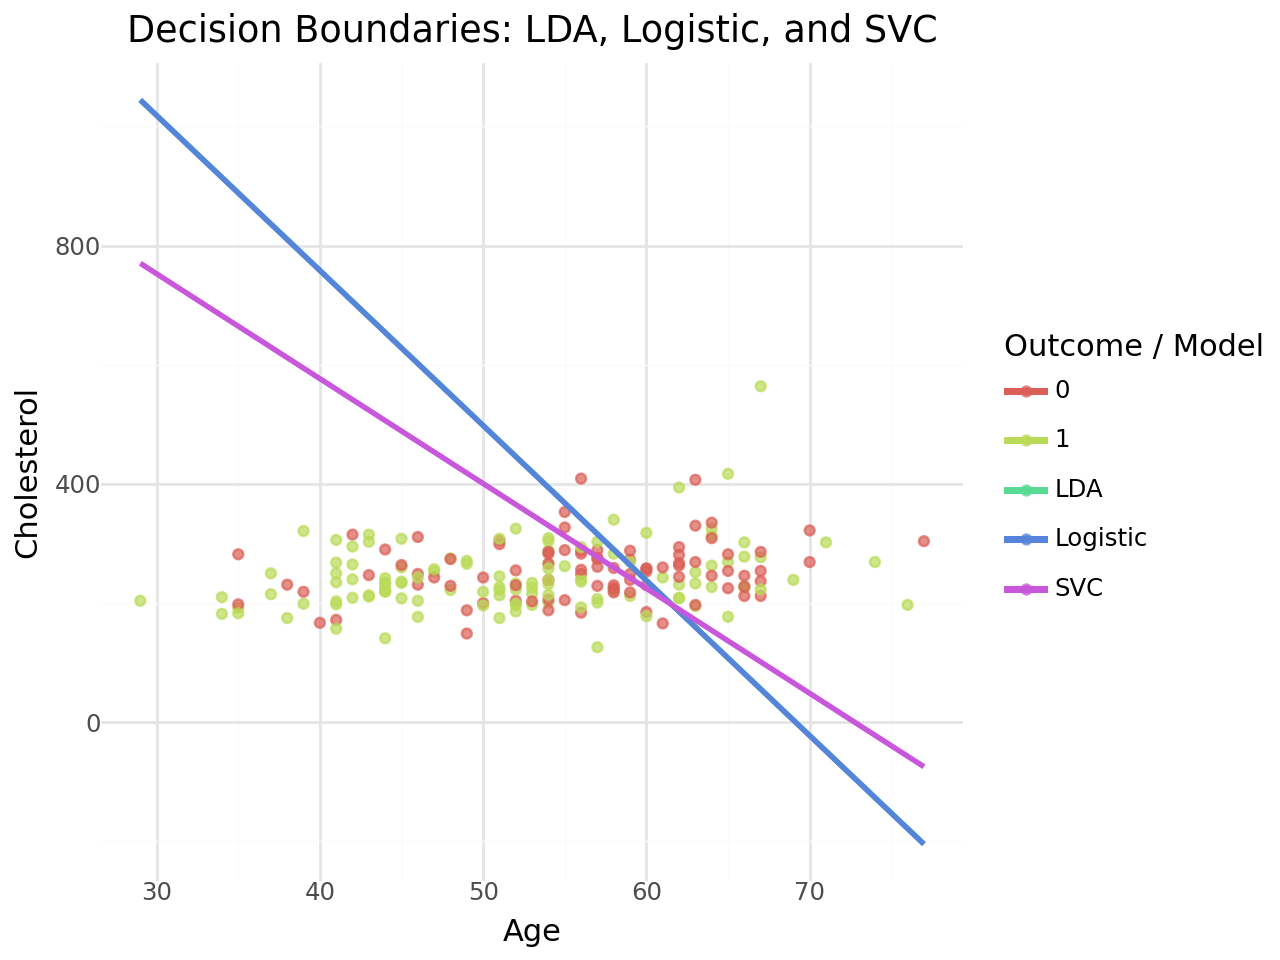

In [ ]:
from plotnine import ggplot, aes, geom_point, geom_line, labs, theme_minimal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np

lda = LinearDiscriminantAnalysis().fit(df[['age', 'chol']], df['diagnosis'])
logreg = LogisticRegression().fit(df[['age', 'chol']], df['diagnosis'])
svc = SVC(kernel='linear', C=1).fit(df[['age', 'chol']], df['diagnosis'])

ages = np.linspace(df['age'].min(), df['age'].max(), 100)
b0_lda, b1_lda, b2_lda = lda.intercept_[0], lda.coef_[0][0], lda.coef_[0][1]
b0_log, b1_log, b2_log = logreg.intercept_[0], logreg.coef_[0][0], logreg.coef_[0][1]
b0_svc, b1_svc, b2_svc = svc.intercept_[0], svc.coef_[0][0], svc.coef_[0][1]

ggplot(df, aes('age', 'chol', color='factor(diagnosis)')) + geom_point(alpha=0.7) + geom_line(boundaries, aes('age', 'chol', color='Model'), size=1.1) + labs(title='Decision Boundaries: LDA, Logistic, and SVC', x='Age', y='Cholesterol', color='Outcome / Model') + theme_minimal()